# Classification by a neural network using Keras -- Penguins Classification

## 0. Import packages and modules

In [82]:
!pwd

/leonardo/home/userexternal/ywang003/multiGPU_AI_TTT_course_DL


In [83]:
!hostname

lrdn3400.leonardo.local


In [84]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sklearn
import tensorflow
import keras

print(sklearn.__version__)
print(tensorflow.__version__)
print(keras.__version__)

1.4.1.post1
2.15.0
2.15.0


In [122]:
# print GPU info

print(tensorflow.config.list_physical_devices('GPU'))

print("Num GPUs Available: ", len(tensorflow.config.list_physical_devices('GPU')))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available:  1


## 1. Formulate/outline the problem: penguin classification

## 2. Identify inputs and outputs

In [85]:
penguins = pd.read_csv('/leonardo/home/userexternal/ywang003/multiGPU_AI_TTT_course_DL/penguins_dataset.csv')
penguins.head()

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [86]:
penguins.shape

(344, 9)

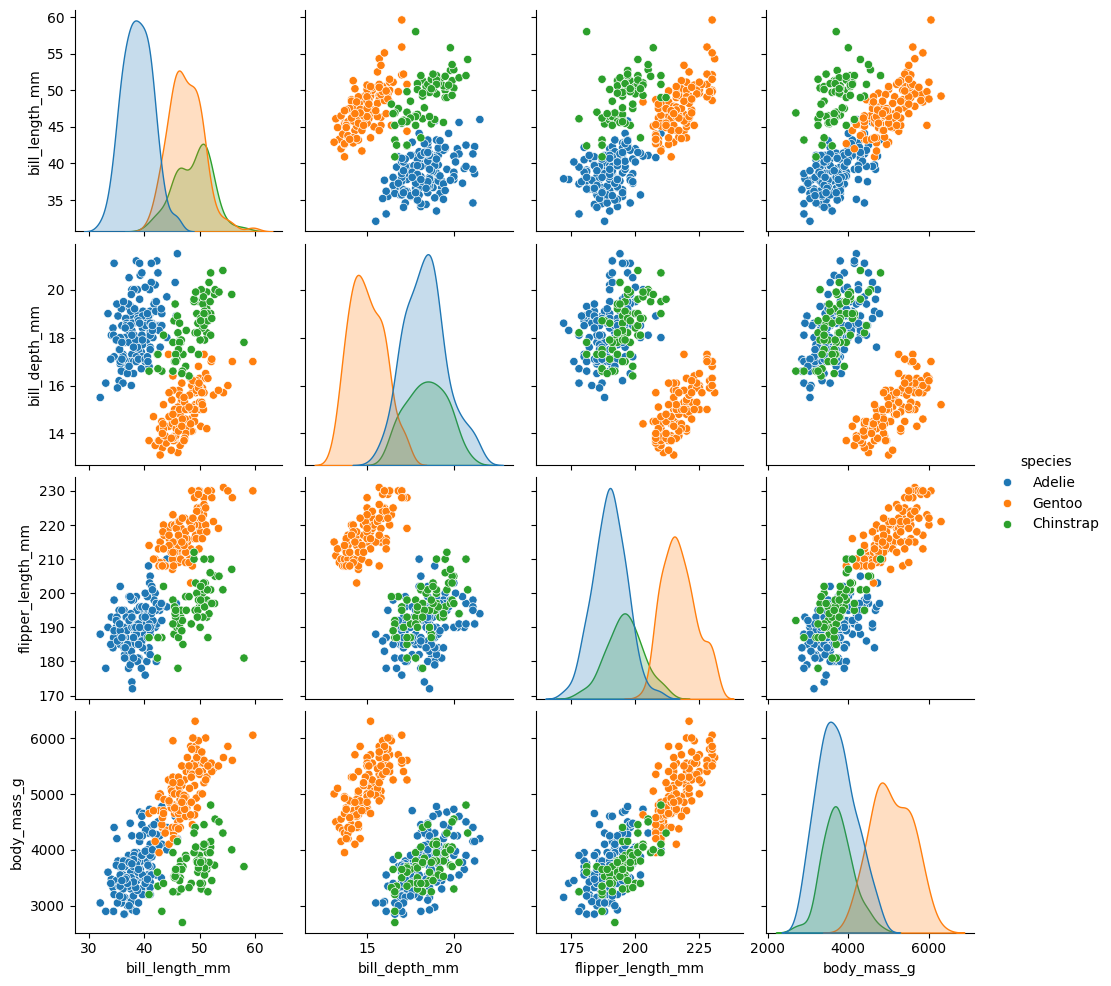

In [87]:
# sns.pairplot(penguins.iloc[:, 1:8], hue="species") # `1:8` means without the first (rowid) and the last column (year)

sns.pairplot(penguins[["species", "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]], hue="species", height=2.5)

## 3. Prepare data

In [88]:
# drop categorical columns

penguins_filtered = penguins.drop(columns=['island', 'sex'])
penguins_filtered.head(7)

,rowid,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,1,Adelie,39.1,18.7,181.0,3750.0,2007
1,2,Adelie,39.5,17.4,186.0,3800.0,2007
2,3,Adelie,40.3,18.0,195.0,3250.0,2007
3,4,Adelie,NaN,NaN,NaN,NaN,2007
4,5,Adelie,36.7,19.3,193.0,3450.0,2007
5,6,Adelie,39.3,20.6,190.0,3650.0,2007
6,7,Adelie,38.9,17.8,181.0,3625.0,2007


In [89]:
# drop rows that have NaN values

penguins_filtered = penguins_filtered.dropna()
penguins_filtered.head(7)

,rowid,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,1,Adelie,39.1,18.7,181.0,3750.0,2007
1,2,Adelie,39.5,17.4,186.0,3800.0,2007
2,3,Adelie,40.3,18.0,195.0,3250.0,2007
4,5,Adelie,36.7,19.3,193.0,3450.0,2007
5,6,Adelie,39.3,20.6,190.0,3650.0,2007
6,7,Adelie,38.9,17.8,181.0,3625.0,2007
7,8,Adelie,39.2,19.6,195.0,4675.0,2007


In [90]:
# Extract columns corresponding to features
features = penguins_filtered.drop(columns=['species'])
features

,rowid,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,1,39.1,18.7,181.0,3750.0,2007
1,2,39.5,17.4,186.0,3800.0,2007
2,3,40.3,18.0,195.0,3250.0,2007
4,5,36.7,19.3,193.0,3450.0,2007
5,6,39.3,20.6,190.0,3650.0,2007
...,...,...,...,...,...,...
339,340,55.8,19.8,207.0,4000.0,2009
340,341,43.5,18.1,202.0,3400.0,2009
341,342,49.6,18.2,193.0,3775.0,2009
342,343,50.8,19.0,210.0,4100.0,2009


In [91]:
target = pd.get_dummies(penguins_filtered['species'])

print(target.head(5))   # print out the top 5 to see what it looks like.

print(target.sample(7)) # randomly pickup 7 examples from the dataset

   Adelie  Chinstrap  Gentoo
0    True      False   False
1    True      False   False
2    True      False   False
4    True      False   False
5    True      False   False
     Adelie  Chinstrap  Gentoo
263   False      False    True
71     True      False   False
70     True      False   False
99     True      False   False
8      True      False   False
245   False      False    True
226   False      False    True


In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=0, shuffle=True, stratify=target)

## 4. Build an architecture from scratch

In [93]:
# set two random seeds, one for numpy and one for tensorflow

from numpy.random import seed
seed(1)

keras.utils.set_random_seed(2)

In [108]:
inputs = keras.Input(shape=(X_train.shape[1],))

In [109]:
hidden_layer = keras.layers.Dense(10, activation="relu")(inputs)

In [110]:
output_layer = keras.layers.Dense(3, activation="softmax")(hidden_layer)

In [111]:
model = keras.Model(inputs=inputs, outputs=output_layer)
model.summary()

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 6)]               0         
                                                                 
 dense_12 (Dense)            (None, 10)                70        
                                                                 
 dense_13 (Dense)            (None, 3)                 33        
                                                                 
Total params: 103 (412.00 Byte)
Trainable params: 103 (412.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 5. Choose a loss function and optimizer

In [112]:
model.compile(optimizer='adam', loss=keras.losses.CategoricalCrossentropy())

In [113]:
history = model.fit(X_train, y_train, epochs=100)

Epoch 1/100
9/9 [==============================] - 0s 2ms/step - loss: 1040.5547
Epoch 2/100
9/9 [==============================] - 0s 1ms/step - loss: 884.8318
Epoch 3/100
9/9 [==============================] - 0s 1ms/step - loss: 791.1799
Epoch 4/100
9/9 [==============================] - 0s 1ms/step - loss: 699.2613
Epoch 5/100
9/9 [==============================] - 0s 1ms/step - loss: 605.4592
Epoch 6/100
9/9 [==============================] - 0s 1ms/step - loss: 510.4855
Epoch 7/100
9/9 [==============================] - 0s 1ms/step - loss: 417.4926
Epoch 8/100
9/9 [==============================] - 0s 1ms/step - loss: 320.5189
Epoch 9/100
9/9 [==============================] - 0s 1ms/step - loss: 225.2063
Epoch 10/100
9/9 [==============================] - 0s 1ms/step - loss: 125.9110
Epoch 11/100
9/9 [==============================] - 0s 1ms/step - loss: 31.3283
Epoch 12/100
9/9 [==============================] - 0s 1ms/step - loss: 11.7593
Epoch 13/100
9/9 [====================

## 7. Perform a prediction/classification

In [114]:
y_pred = model.predict(X_test)
prediction = pd.DataFrame(y_pred, columns=target.columns)
prediction

3/3 [==============================] - 0s 1ms/step


,Adelie,Chinstrap,Gentoo
0,3.814210e-08,0.000000e+00,1.000000e+00
1,1.000000e+00,0.000000e+00,3.502365e-20
2,9.999900e-01,9.344084e-36,1.000380e-05
3,8.908479e-16,5.563760e-08,1.000000e+00
4,2.147878e-30,1.000000e+00,5.215463e-35
...,...,...,...
64,1.000000e+00,1.615085e-33,0.000000e+00
65,1.000000e+00,3.820995e-31,0.000000e+00
66,3.579244e-20,1.000000e+00,0.000000e+00
67,4.324698e-33,6.796305e-28,1.000000e+00


In [115]:
predicted_species = prediction.idxmax(axis="columns")
predicted_species

0        Gentoo
1        Adelie
2        Adelie
3        Gentoo
4     Chinstrap
        ...    
64       Adelie
65       Adelie
66    Chinstrap
67       Gentoo
68       Gentoo
Length: 69, dtype: object

## 8. Measuring performance

In [116]:
from sklearn.metrics import confusion_matrix

true_species = y_test.idxmax(axis="columns")

matrix = confusion_matrix(true_species, predicted_species)
print(matrix)

[[28  0  2]
 [ 0 14  0]
 [ 1  0 24]]


In [117]:
# Convert to a pandas dataframe
confusion_df = pd.DataFrame(matrix, index=y_test.columns.values, columns=y_test.columns.values)

# Set the names of the x and y axis, this helps with the readability of the heatmap.
confusion_df.index.name = 'True Label'
confusion_df.columns.name = 'Predicted Label'
confusion_df.head()

Predicted Label,Adelie,Chinstrap,Gentoo
True Label,,,
Adelie,28,0,2
Chinstrap,0,14,0
Gentoo,1,0,24


<Axes: xlabel='Predicted Label', ylabel='True Label'>

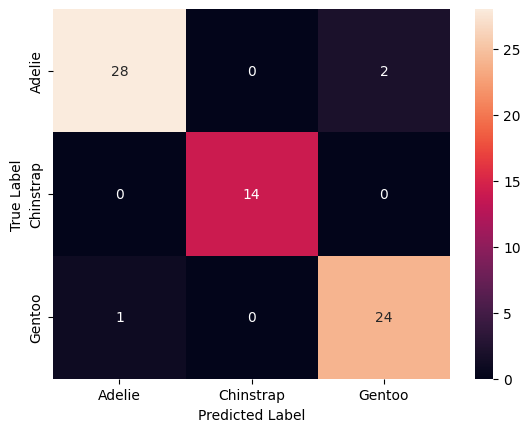

In [118]:
sns.heatmap(confusion_df, annot=True)

## 9. Refine the model

## 10. Share model

In [119]:
model.save('penguins_classification.keras')

In [120]:
pretrained_model = keras.models.load_model('penguins_classification.keras')

In [121]:
# use the pretrained model here
y_pretrained_pred = pretrained_model.predict(X_test)
pretrained_prediction = pd.DataFrame(y_pretrained_pred, columns=target.columns.values)

# idxmax will select the column for each row with the highest value
pretrained_predicted_species = pretrained_prediction.idxmax(axis="columns")
print(pretrained_predicted_species)

3/3 [==============================] - 0s 1ms/step
0        Gentoo
1        Adelie
2        Adelie
3        Gentoo
4     Chinstrap
        ...    
64       Adelie
65       Adelie
66    Chinstrap
67       Gentoo
68       Gentoo
Length: 69, dtype: object
